In [39]:
#dropping duplicate values - checking if there are any duplicate rows and dropping if any
data=data.drop_duplicates()
print('data shape:', data.shape)
# There is no duplication
print('No duplication value')

NameError: name 'data' is not defined

In [ ]:
# Check for zeros in the entire DataFrame
zero_values = (data == 0).sum()
print("Number of zeros in each column:")
print(zero_values)


 According to above, we can observe that  "concavity_mean", "concave points_mean" ","concavity_se","concave points_se", "concavity_worst" and "concave points_worst" have zero values. 

In [ ]:
# Handle issues related to zero values in the dataset
# We are checking the rows conating zero values.
print(data[data['concavity_mean']==0].shape[0])
print(data[data['concave points_mean']==0].shape[0])
print(data[data['concavity_se']==0].shape[0])
print(data[data['concave points_se']==0].shape[0])
print(data[data['concavity_worst']==0].shape[0])
print(data[data['concave points_worst']==0].shape[0])

In [ ]:
# replace with median or mean
data['concavity_mean']=data['concavity_mean'].replace(0,data['concavity_mean'].median())#skewed distribution (median)
data['concave points_mean']=data['concave points_mean'].replace(0,data['concave points_mean'].median())#skewed distribution (median)
data['concavity_se']=data['concavity_se'].replace(0,data['concavity_se'].median())#skewed distribution (median)
data['concave points_se']=data['concave points_se'].replace(0,data['concave points_se'].median())#skewed distribution (median)
data['concavity_worst']=data['concavity_worst'].replace(0,data['concavity_worst'].median())#skewed distribution (median)
data['concave points_worst']=data['concave points_worst'].replace(0,data['concave points_worst'].median())#skewed distribution (median)

In [ ]:
data.shape

In [ ]:
# Plotting boxplots for each column to see the outliers 
fig, axes = plt.subplots(nrows=11, ncols=3, figsize=(15, 30))  
for i, col in enumerate(data.columns):
    ax = axes[i // 3, i % 3]
    data.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Handling potential outliers and rescale the data appropriately
# We use Quantile Transformer : This method transforms the features to follow a uniform or a normal distribution.
# Therefore, for a given feature, this transformation tends to spread out the most frequent values. 
# It also reduces the impact of (marginal) outliers: this is therefore a robust preprocessing scheme.

from sklearn.preprocessing import QuantileTransformer
x=data
quantile  = QuantileTransformer()
X = quantile.fit_transform(x)
df_new=quantile.transform(X)
df_new=pd.DataFrame(X)
df_new.columns =['diagnosis','radius_mean', 'texture_mean','perimeter_mean','area_mean','smoothness_mean','compactness_mean','concavity_mean','concave points_mean','symmetry_mean','fractal_dimension_mean','radius_se','texture_se','perimeter_se','area_se','smoothness_se','compactness_se','concavity_se','concave points_se','symmetry_se','fractal_dimension_se','radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst','concave points_worst','symmetry_worst','fractal_dimension_worst']
df_new.head()

We see that there are not any more outliers after using the Quantile Transformer.

<span style="font-size:x-large; color:blue; font-weight:bold;"> Part 2: Modeling & Evaluation</span>


We consider exploring with a wider range of machine learning algorithms. This experiment can provide insights into which algorithms perform optimally for our specific dataset and problem. Since we are dealing with supervised data with labeled attributes and discrete outputs, we will work with various classifier algorithms. 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import GridSearchCV

In [ ]:
# Split dataset into train (80%) and test (20%) and build predictive models
target_name='diagnosis'
y= df_new[target_name]#given predictions - training data 
X=df_new.drop(target_name,axis=1)#dropping the Outcome column and keeping all other columns as X
#splitting data in 80% train, 20%test
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=0)
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

# K-Nearest Neighbours

We implement hyperparameter tuning for a K-Nearest Neighbors (KNN) classifier using grid search with cross-validation. It searches over a range of hyperparameters including the number of neighbors (n_neighbors), the distance metric (metric), the type of distance calculation (p), and the weighting scheme for neighbors (weights). The model is evaluated on a test set using classification metrics such as precision, recall, and F1-score. Overall, this approach aims to find the optimal configuration for the KNN model to maximize its predictive performance.

In [ ]:
#List Hyperparameters to tune
knn= KNeighborsClassifier()
n_neighbors = list(range(1,20))
p=[1,2]
weights = ['uniform', 'distance']
metric = ['euclidean', 'manhattan', 'minkowski']

#convert to dictionary
hyperparameters = dict(n_neighbors=n_neighbors, p=p,weights=weights,metric=metric)

#Making model
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=knn, param_grid=hyperparameters, n_jobs=-1, cv=cv, scoring='f1',error_score=0)

In [ ]:
# Fit the model
best_model = grid_search.fit(X_train,y_train)

In [ ]:
#Best Hyperparameters Value
print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
print('Best p:', best_model.best_estimator_.get_params()['p'])
print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])

In [ ]:
# knn model with k = 3
KNN = KNeighborsClassifier(n_neighbors=3)

In [ ]:
#Predict testing set
knn_pred = best_model.best_estimator_.predict(X_test)


In [ ]:
print("Classification Report is:\n",classification_report(y_test,knn_pred))
print("\n F1:\n",f1_score(y_test,knn_pred))
print("\n Precision score is:\n",precision_score(y_test,knn_pred))
print("\n Recall score is:\n",recall_score(y_test,knn_pred))
print("\n Accuracy score is:\n",accuracy_score(y_test, knn_pred))

In [ ]:
import tensorflow as tf

cm_knn = tf.math.confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Conclusion:  
The classification report indicates good precision, recall, and F1-score values for both classes (0 and 1), with an overall accuracy of 95% indicating that the model performs well on the test data. 

# Naive Bayes

We perform hyperparameter tuning using GridSearchCV with Naive Bayes classifier (GaussianNB). It utilizes a grid of var_smoothing values to find the best parameter through cross-validation. The classification report and evaluation metrics are printed after making predictions using the best model found by GridSearchCV. This approach helps in optimizing the performance of the Naive Bayes classifier by selecting the most suitable value for var_smoothing.

In [ ]:
from sklearn.naive_bayes import GaussianNB


param_grid_nb = {
    'var_smoothing': np.logspace(0,-2, num=100)
}
nbModel_grid = GridSearchCV(estimator=GaussianNB(), param_grid=param_grid_nb, verbose=1, cv=10, n_jobs=-1)

In [ ]:
best_model1 = nbModel_grid.fit(X_train, y_train)

In [ ]:
nb_pred=best_model1.predict(X_test)

In [ ]:
print("Classification Report is:\n",classification_report(y_test,nb_pred))
print("\n F1:\n",f1_score(y_test,nb_pred))
print("\n Precision score is:\n",precision_score(y_test,nb_pred))
print("\n Recall score is:\n",recall_score(y_test,nb_pred))
print("\n Accuracy score is:\n",accuracy_score(y_test, nb_pred))

In [ ]:
import tensorflow as tf

cm_nb = tf.math.confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Conclusion:

The overall accuracy of the model is 91%, indicating that 91% of the predictions made by the model are correct.

# Support Vector Machine

SVM is a powerful algorithm for classification tasks, particularly when dealing with complex decisions. The hyperparameters being tuned include the choice of kernel function, the regularization parameter C, and the kernel coefficient gamma. The grid search optimizes these hyperparameters to maximize the F1 score and accuracy that balances precision and recall. 

In [ ]:
from sklearn.svm import SVC

In [ ]:
svc = SVC()

In [ ]:
kernel = ['poly', 'rbf', 'sigmoid']
C = [50, 10, 1.0, 0.1, 0.01]
gamma = ['scale']

In [ ]:
# define grid search
grid = dict(kernel=kernel,C=C,gamma=gamma)
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=svc, param_grid=grid, n_jobs=-1, cv=cv, scoring='f1',error_score=0)

In [ ]:
SVC_model = grid_search.fit(X_train, y_train)

In [ ]:
svm_pred=SVC_model.predict(X_test)

In [ ]:
print("Classification Report is:\n",classification_report(y_test,svm_pred))
print("\n F1:\n",f1_score(y_test,svm_pred))
print("\n Precision score is:\n",precision_score(y_test,svm_pred))
print("\n Recall score is:\n",recall_score(y_test,svm_pred))
print("\n Accuracy score is:\n",accuracy_score(y_test, svm_pred))

In [ ]:
import tensorflow as tf

cm_svm = tf.math.confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

<span style="font-size:small; color:blue; font-weight:bold;"> Conclusion: </span>
With precision, recall, and F1-score all around 98-99%, the model demonstrates strong capability in both correctly identifying benign and malevolent cases. The high F1-score suggests a good balance between precision and recall, indicating few false positives and false negatives. Overall, the model achieves an accuracy of 98%, making it highly reliable for classification tasks.

# Decision Tree 

Decision Trees are very effective when it comes to classification tasks, especially when interpretability, non-linearity, feature importance, and smoothness of use are important considerations. We create a Decision Tree classifier object with a random state of 42 and define a grid of hyperparameters for the Decision Tree classifier. We use GridSearchCV to search for the best combination of hyperparameters. After fitting the model on the training set, we evaluate its performance on the test set, whose evaluation metrics are provided in the end. 

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize decision tree classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

In [ ]:
# Create the parameter grid based on the results of random search 
params = {
    'max_depth': [5, 10, 20,25],
    'min_samples_leaf': [10, 20, 50, 100,120],
    'criterion': ["gini", "entropy"]
}

In [ ]:
grid_search = GridSearchCV(estimator=dt, 
                           param_grid=params, 
                           cv=4, n_jobs=-1, verbose=1, scoring = "accuracy")

In [ ]:
best_model=grid_search.fit(X_train, y_train)

In [ ]:
dt_pred=best_model.predict(X_test)

In [ ]:
print("Classification Report is:\n",classification_report(y_test,dt_pred))
print("\n F1:\n",f1_score(y_test,dt_pred))
print("\n Precision score is:\n",precision_score(y_test,dt_pred))
print("\n Recall score is:\n",recall_score(y_test,dt_pred))
print("\n Accuracy score is:\n",accuracy_score(y_test, dt_pred))

In [ ]:
import tensorflow as tf

cm_dt = tf.math.confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

<span style="font-size:small; color:blue; font-weight:bold;"> Conclusion: </span>
The precision score indicates that when the model predicts a class label, it is correct about 90% of the time for class 0 and 98% of the time for class 1. The recall score indicates that the model correctly identifies about 98% of the actual instances of class 0 and about 93% of the actual instances of class 1. The F1 score is 0.94 for class 0 and 0.95 for class 1, indicating a good balance between precision and recall for both classes. The overall accuracy of the model is 95%, indicating that 95% of the predictions made by the model are correct. The overall performance is quite good, with high precision, recall, and F1-score values for both classes.

# Random Forest

We have used random forest classifier for its efficiency in handling complex datasets. We initialize the RandomForestClassifier class and set random_state=42 to ensure reproducibility of results. Exploring different values for n_estimators (number of trees in the forest) and max_features (number of features to consider when looking for the best split) provides us an option to obtain a combination that optimizes model performance. We are using GridSearchCV to perform an exhaustive search over the specified hyperparameter grid. This involves training the RF model with different combinations of hyperparameters and evaluating each combination with cross-validation. Finally, we fit the model on the training data,to evaluate its performance on the test set using various metrics such as precision, recall, F1-score, and confusion matrix.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# define models and parameters
model = RandomForestClassifier(random_state=42)

n_estimators = [100, 500, 1000]  # Explore different values
max_features = ['sqrt', 'log2', None]  # Explore different options including None

In [ ]:
# define grid search
grid = dict(n_estimators=n_estimators,max_features=max_features)

# Initialize cross-validation
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

# Perform grid search
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)

In [ ]:
best_model = grid_search.fit(X_train, y_train)

In [ ]:
rf_pred=best_model.predict(X_test)

In [ ]:
print("Classification Report is:\n",classification_report(y_test,rf_pred))
print("\n F1:\n",f1_score(y_test,rf_pred))
print("\n Precision score is:\n",precision_score(y_test,rf_pred))
print("\n Recall score is:\n",recall_score(y_test,rf_pred))
print("\n Accuracy score is:\n",accuracy_score(y_test, rf_pred))

In [ ]:
import tensorflow as tf

cm_rf = tf.math.confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

<span style="font-size:small; color:blue; font-weight:bold;"> Conclusion: </span>
The precision score indicates that when the model predicts a class label, it is correct about 96% of the time for class 0 and 98% of the time for class 1. The recall score indicates that the model identifies about 98% of the actual instances of class 0 and about 97% of the actual instances of class 1. The F1-score is of 0.97 for class 0 and 0.98 for class 1 indicates a good balance between precision and recall for both classes. The overall accuracy of the model is 97, indicating that 97% of the predictions made by the model are correct. 

# Logistic Regression

We use the logistic regression model to predict binary outcomes by estimating the probabilities using a logistic function and then making predictions based on a threshold. The max_iter parameter is set to 1000 to ensure convergence, and random_state is set to 42 for reproducibility. After training, the model is used to make predictions on the test dataset. Performance metrics such as precision, recall, F1-score, and a classification report are calculated to evaluate the model's performance in terms of its ability to correctly classify instances. 

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Initialize logistic regression model
reg = LogisticRegression(max_iter=1000, random_state=42)

# Train logistic regression model
reg.fit(X_train, y_train)

In [ ]:
lr_pred=reg.predict(X_test)

In [ ]:
print("Classification Report is:\n",classification_report(y_test,lr_pred))
print("\n F1:\n",f1_score(y_test,lr_pred))
print("\n Precision score is:\n",precision_score(y_test,lr_pred))
print("\n Recall score is:\n",recall_score(y_test,lr_pred))
print("\n Accuracy score is:\n",accuracy_score(y_test, lr_pred))

In [ ]:
import tensorflow as tf

cm_lr = tf.math.confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

<span style="font-size:small; color:blue; font-weight:bold;"> Conclusion: </span>
The precision for class 0 is 0.92, indicating that among all instances predicted as class 0, 92% were actually class 0. For class 1, the precision is higher at 0.98, indicating that among all instances predicted as class 1, 98% were actually class 1. The recall for class 0 is 0.98, indicating that the model correctly identified 98% of all actual class 0 instances. For class 1, the recall is slightly lower at 0.94, meaning that the model correctly identified 94% of all actual class 1 instances.The overall accuracy of the model is 0.96, which means that it correctly classified 96% of all instances in the test dataset.
Overall, the model demonstrates strong performance in terms of precision, recall, and F1-score, suggesting it effectively distinguishes between the two classes. 

# XGBOOST

XGBoost is an efficient and scalable implementation of gradient boosting framework. It's an ensemble learning method that builds a sequence of weak models such as decision trees and combines them to create a strong model. 

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from xgboost.sklearn import XGBClassifier

In [ ]:
#xg boost

xgb_model = xgb.XGBClassifier(random_state=42)

In [ ]:
# Train XGBoost classifier
xgb_model.fit(X_train, y_train)

In [ ]:
# Make predictions
xgb_pred = xgb_model.predict(X_test)

In [ ]:
print("Classification Report is:\n", classification_report(y_test, xgb_pred))
print("\n F1:\n", f1_score(y_test, xgb_pred))
print("\n Precision score is:\n", precision_score(y_test, xgb_pred))
print("\n Recall score is:\n", recall_score(y_test, xgb_pred))
print("\n Accuracy score is:\n",accuracy_score(y_test, xgb_pred))

In [ ]:
import tensorflow as tf

cm_xgb = tf.math.confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

<span style="font-size:small; color:blue; font-weight:bold;"> Conclusion: </span>
Th model corrects approximately 94% and 97% of the time for class 0 and class 1 respectively. The model also correctly identifies around 96% of the actual positives for both classes. The overall accuracy of the model is 96%, indicating the proportion of correctly classified samples out of the total samples, thus making the model very effective.

<span style="font-size:x-large; color:blue; font-weight:bold;"> Part 3 : Feature importance analysis</span> 

We would like to conduct feature importance analysis on some selected models. Understanding which symptoms contribute significantly to disease prediction can provide valuable insights for healthcare professionals. Decision trees and random forests provide a natural way to measure feature importance based on how frequently the variables are used to make decisions. XGBoost also offers built-in methods to compute feature importance based on the contribution of each feature to the model's performance improvement. In their respective graphs, each bar represents the relative importance of a feature in the decision tree model. Clearly, we see that concave points_worst has the highest importance.

Models like Logistic Regression can also indicate the importance of features based on the coefficients. The coefficients directly indicate the strength and direction of the relationship between each attribute and the target variable 'diagnosis'. If the absolute coefficients are larger, it suggests more importance. We can see that texture_worst has the most significant impact on the model's predictions.

In [ ]:
feature_importance_dt = dt.feature_importances_
# make importances relative to max importance
feature_importance_dt = 100.0 * (feature_importance_dt / feature_importance_dt.max())
sorted_idx = np.argsort(feature_importance_dt)
pos = np.arange(sorted_idx.shape[0]) + .5
plt.figure(figsize=(15, 15))  # Adjust figure size if needed
plt.barh(pos, feature_importance_dt[sorted_idx], align='center')
plt.yticks(pos, X_train.columns[sorted_idx])  # Replace X_train with your feature DataFrame
plt.xlabel('Relative Importance')
plt.title('Variable Importance (Decision Tree)')
plt.show()

In [ ]:
# Extract feature importances
feature_importances_rf = best_model.best_estimator_.feature_importances_

# Sort feature importances
sorted_idx = np.argsort(feature_importances_rf)
pos = np.arange(sorted_idx.shape[0]) + .5

# Plot feature importances
plt.figure(figsize=(15, 15))
plt.barh(pos, feature_importances_rf[sorted_idx], align='center')
plt.yticks(pos, X_train.columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Variable Importance (Random Forest)')
plt.show()

In [ ]:
# Get feature coefficients
feature_coefficients = reg.coef_[0]

# Sort feature coefficients
sorted_idx = np.argsort(np.abs(feature_coefficients))

# Plot feature coefficients
plt.figure(figsize=(10, 8))
plt.barh(range(len(sorted_idx)), np.abs(feature_coefficients[sorted_idx]), align='center')
plt.yticks(range(len(sorted_idx)), X_train.columns[sorted_idx])
plt.xlabel('Absolute Coefficient Value')
plt.title('Feature Importance (Absolute Coefficients)')
plt.show()

In [ ]:
# Get feature importances
feature_importances_xgb = xgb_model.feature_importances_

# Sort feature importances
sorted_idx = np.argsort(feature_importances_xgb)
pos = np.arange(sorted_idx.shape[0]) + .5

# Plot feature importances
plt.figure(figsize=(10, 8))
plt.barh(pos, feature_importances_xgb[sorted_idx], align='center')
plt.yticks(pos, X_train.columns[sorted_idx])
plt.xlabel('Relative Importance')
plt.title('Feature Importance (XGBoost)')
plt.show()

<span style="font-size:x-large; color:blue; font-weight:bold;"> Part 4 : Ensemble Methods</span>

# Ensemble Voting classifier

In [ ]:
!pip install mlxtend

In [ ]:
!pip install mlxtend --upgrade 

We are opting for hard voting since we are more concerned about accuracy of the.

In [ ]:
from mlxtend.classifier import EnsembleVoteClassifier
from sklearn import model_selection
import sklearn.metrics as metrics
from sklearn import preprocessing
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
# Initialize classifiers
LR = LogisticRegression(random_state=2017)
RF = RandomForestClassifier(n_estimators=100, random_state=2017)
SVM = SVC(random_state=0, probability=True)
KNC = KNeighborsClassifier()
DTC = DecisionTreeClassifier()
NB = GaussianNB()  # GausssianNB

XGB = XGBClassifier(random_state=2017) 

clfs = []

print('5-fold cross validation:\n')
for clf, label in zip([LR, RF, SVM, KNC, DTC, NB, XGB],
                      ['Logistic Regression',
                       'Random Forest',
                       'Support Vector Machine',
                       'KNeighbors',
                       'Decision Tree',
                       'Naive Bayes',
                       'XGBoost']):
    scores = model_selection.cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy') 
    print("Train CV Accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))
    md = clf.fit(X_train, y_train)
    clfs.append(md)
print("Test Accuracy: %0.2f " % (metrics.accuracy_score(clf.predict (X_test), y_test)))

In [ ]:
# ### Ensemble Voting
clfs = []
print('5-fold cross validation:\n')
ECH = EnsembleVoteClassifier(clfs=[LR, RF, SVM, KNC, DTC, NB, XGB], voting='hard')
ECS = EnsembleVoteClassifier(clfs=[LR, RF, SVM, KNC, DTC, NB, XGB], voting='soft', weights=[1,1,1, 1, 1,1,1])
for clf, label in zip([ECH, ECS],
                      ['Ensemble Hard Voting',
                       'Ensemble Soft Voting']):
    scores = model_selection.cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print("Train CV Accuracy: %0.2f (+/- %0.2f) [%s]" % (scores.mean(), scores.std(), label))

md = clf.fit(X_train, y_train)
clfs.append(md)
print("Test Accuracy: %0.2f " % (metrics.accuracy_score(clf.predict (X_test), y_test))) 

<span style="font-size:small; color:blue; font-weight:bold;"> Conclusion: </span>
We see that the models perform well on the training data, with the best-performing classifier achieving a high accuracy of 96% on the test data. The ensemble soft voting classifier appears to be a robust and reliable model by achieving a cross-validation accuracy of approximately 96% with a small standard deviation of 0.01.

<span style="font-size:x-large; color:blue; font-weight:bold;"> Part 5 : Deep Learning (Neural Network) </span> 

Using a deep learning (neural network) for analyzing this dataset is also a suitable option, since it offers numeerous benefits in terms of feature learning, catching non-linear relationships, and achieving high performance.

In [ ]:
pip install keras

In [ ]:
pip install --upgrade tensorflow

In [ ]:
from keras.layers import Dense, Activation, Dropout
from keras.models import Sequential

The neural network architecture consists of two hidden layers, each with 64 neurons and ReLU activation function. We add Dropout layers with a dropout rate of 0.5 after each hidden layer to prevent overfitting. The output layer consists of a single neuron with a sigmoid activation function, since we are dealing with binary classification tasks. The model is compiled using binary cross-entropy loss and the Adam optimizer, and we use accuracy as the evaluation metric.

In [ ]:
# Define the neural network architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Adjust input shape here
    Dropout(0.5),  # Add dropout layer with dropout rate of 0.5
    Dense(64, activation='relu'),
    Dropout(0.5),  # Add dropout layer with dropout rate of 0.5
    Dense(1, activation='sigmoid')
])

# compile the keras model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# fit the keras model on the dataset
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=32)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print('Test Loss:', test_loss)
print('Test Accuracy:', test_accuracy)

In [ ]:
model.summary()

<span style="font-size:small; color:blue; font-weight:bold;"> Conclusion: </span> 
After conducting the training process over 100 epochs, we see that the test accuracy is approximately 95.61%. It indicates that the model performs well on unseen data, suggesting that it has learned meaningful patterns from the training data and can generalize to the testing data effectively. The test data loss is approximately 0.0876. It represents the average loss across all samples in the test dataset. Since it is relatively low, it indicates that the model's predictions are quite close to the actual labels on the test dataset, suggesting that the model performs well in making predictions on unseen data.

<span style="font-size:x-large; color:blue; font-weight:bold;"> Part 6 : Deployment </span>

# Prediction

In [ ]:
import warnings #avoid warning flash
warnings.filterwarnings('ignore')

In [ ]:
SVC_model.predict([[0.1,2.1,0.9,0.8,0.2,0.1,2.1,0.9,.8,0.2,1,3,0.9,0.1,2.1,0.9,0.8,0.2,0.1,2.1,0.9,.8,0.2,1,3,0.9,0.2,1,3,0.9]])

In [ ]:
SVC_model.predict([[13.54, 14.36, 87.46, 566.3, 0.09779, 0.08129, 0.06664, 0.04781, 0.1885, 0.05766, 0.2699, 0.7886, 2.058, 23.56, 0.008462, 0.0146, 0.02387, 0.01315, 0.0198, 0.0023, 15.11, 19.26, 99.7, 711.2, 0.144, 0.1773, 0.239, 0.1288, 0.2977, 0.07259]])

In [ ]:
SVC_model.predict([[20.18, 23.97, 143.7, 1245, 0.1286, 0.3454, 0.3754, 0.1604, 0.2906, 0.08142, 0.9317, 1.885, 8.649, 116.4, 0.01038, 0.06835, 0.1091, 0.02593, 0.07895, 0.005987, 23.37, 31.72, 170.3, 1623, 0.1639, 0.6164, 0.7681, 0.2508, 0.544, 0.09964]])

In [ ]:
SVC_model.predict([[17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.2419,0.07871,1.095,0.9053,8.589,153.4,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189]])

# Deployment in Streamlit

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Fri April 05 2024


@author: Group_12 (Masoomeh Akbari, Lord Kavi, Mitra Mansouri, Prangya Parida )
"""


import pickle
import streamlit as st


# loading the trained model
pickle_in = open('classifier.pkl', 'rb')
classifier = pickle.load(pickle_in)


@st.cache()


# defining the function which will make the prediction using the data which the user inputs




def prediction(radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave_points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave_points_worst, symmetry_worst, fractal_dimension_worst):
    
    # Making predictions
    prediction = classifier.predict([[radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave_points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave_points_worst, symmetry_worst, fractal_dimension_worst]])
    print(prediction)
    return prediction




# this is the main function in which we define our webpage
def main():
    st.title("Breast Cancer Diagnostic")
    # front end elements of the web page
    html_temp = """
    <div style ="background-color:gray;padding:13px">
    <h1 style ="color:black;text-align:center;">Streamlit Breast Cancer Diagnostic ML App</h1>
    </div>
    """


    # display the front end aspect
    st.markdown(html_temp, unsafe_allow_html = True)


    # following lines create boxes in which user can enter data required to make prediction
    # Collect user input
    radius_mean = st.text_input("Radius Mean", "Type Here")
    texture_mean = st.text_input("Texture Mean", "Type Here")
    perimeter_mean = st.text_input("Perimeter Mean", "Type Here")
    area_mean = st.text_input("Area Mean", "Type Here")
    smoothness_mean = st.text_input("Smoothness Mean", "Type Here")
    compactness_mean = st.text_input("Compactness Mean", "Type Here")
    concavity_mean = st.text_input("Concavity Mean", "Type Here")
    concave_points_mean = st.text_input("Concave Points Mean", "Type Here")
    symmetry_mean = st.text_input("Symmetry Mean", "Type Here")
    fractal_dimension_mean = st.text_input("Fractal Dimension Mean", "Type Here")
    radius_se = st.text_input("Radius SE", "Type Here")
    texture_se = st.text_input("Texture SE", "Type Here")
    perimeter_se = st.text_input("Perimeter SE", "Type Here")
    area_se = st.text_input("Area SE", "Type Here")
    smoothness_se = st.text_input("Smoothness SE", "Type Here")
    compactness_se = st.text_input("Compactness SE", "Type Here")
    concavity_se = st.text_input("Concavity SE", "Type Here")
    concave_points_se = st.text_input("Concave Points SE", "Type Here")
    symmetry_se = st.text_input("Symmetry SE", "Type Here")
    fractal_dimension_se = st.text_input("Fractal Dimension SE", "Type Here")
    radius_worst = st.text_input("Radius Worst", "Type Here")
    texture_worst = st.text_input("Texture Worst", "Type Here")
    perimeter_worst = st.text_input("Perimeter Worst", "Type Here")
    area_worst = st.text_input("Area Worst", "Type Here")
    smoothness_worst = st.text_input("Smoothness Worst", "Type Here")
    compactness_worst = st.text_input("Compactness Worst", "Type Here")
    concavity_worst = st.text_input("Concavity Worst", "Type Here")
    concave_points_worst = st.text_input("Concave Points Worst", "Type Here")
    symmetry_worst = st.text_input("Symmetry Worst", "Type Here")
    fractal_dimension_worst = st.text_input("Fractal Dimension Worst", "Type Here")
    result=""
    # Make prediction on user input
    if st.button("Predict"):
        # Ensure all fields are filled
        if all([value != "Type Here" for value in [radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave_points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave_points_worst, symmetry_worst, fractal_dimension_worst]]):
            #features = [radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave_points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave_points_worst, symmetry_worst, fractal_dimension_worst]
            result1 = prediction(radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave_points_mean, symmetry_mean, fractal_dimension_mean, radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave_points_se, symmetry_se, fractal_dimension_se, radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave_points_worst, symmetry_worst, fractal_dimension_worst)
            result = "Malignant" if result1[0] == 1 else "Benign"
            #st.write("Predicted diagnosis is {}".format(result))
            st.success("Predicted diagnosis is {}".format(result))
        else:
            st.write("Please fill in all input fields.")
    #result=""




if __name__=='__main__':
    main()

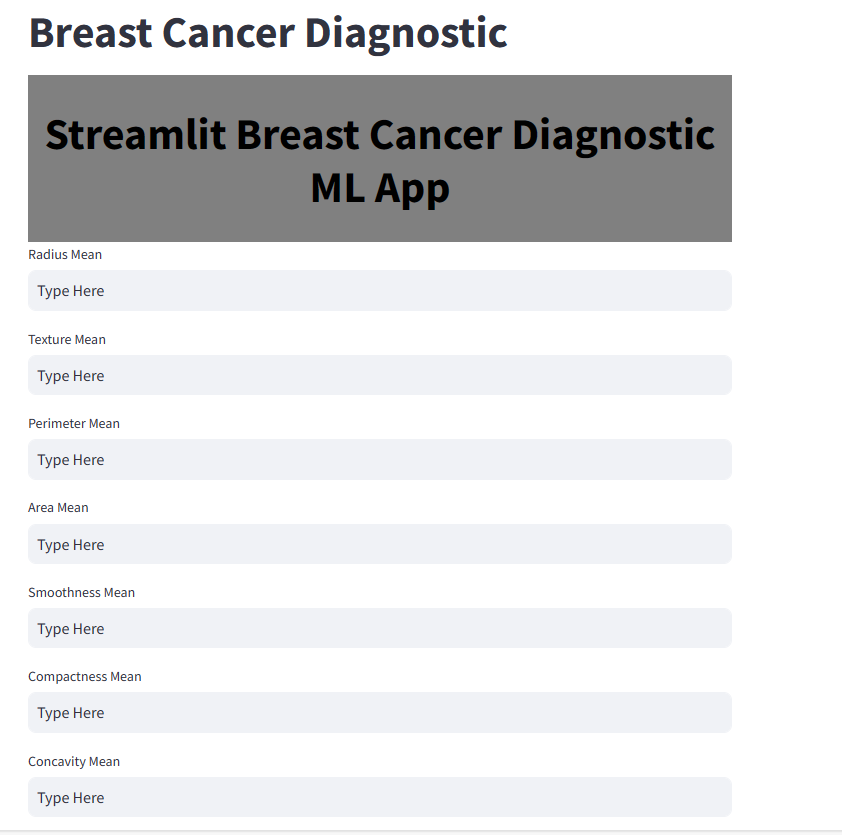